In [57]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [58]:
#Import the dataset file
data=pd.read_csv("students_adaptability_level_online_education.csv")
data

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,Boy,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,4G,3-6,No,Tab,Moderate
1,Girl,21-25,University,Non Government,No,Yes,High,Mid,Mobile Data,4G,1-3,Yes,Mobile,Moderate
2,Girl,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Moderate
3,Girl,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,Girl,16-20,College,Non Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Low
1201,Girl,16-20,College,Non Government,No,No,High,Mid,Wifi,4G,3-6,No,Mobile,Moderate
1202,Boy,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,3G,1-3,No,Mobile,Moderate
1203,Girl,16-20,College,Non Government,No,No,Low,Mid,Wifi,4G,1-3,No,Mobile,Low


In [11]:
!pip install pandas_profiling

In [12]:
data.isna().sum()

Gender                 0
Age                    0
Education Level        0
Institution Type       0
IT Student             0
Location               0
Load-shedding          0
Financial Condition    0
Internet Type          0
Network Type           0
Class Duration         0
Self Lms               0
Device                 0
Adaptivity Level       0
dtype: int64

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               1205 non-null   object
 1   Age                  1205 non-null   object
 2   Education Level      1205 non-null   object
 3   Institution Type     1205 non-null   object
 4   IT Student           1205 non-null   object
 5   Location             1205 non-null   object
 6   Load-shedding        1205 non-null   object
 7   Financial Condition  1205 non-null   object
 8   Internet Type        1205 non-null   object
 9   Network Type         1205 non-null   object
 10  Class Duration       1205 non-null   object
 11  Self Lms             1205 non-null   object
 12  Device               1205 non-null   object
 13  Adaptivity Level     1205 non-null   object
dtypes: object(14)
memory usage: 131.9+ KB


In [18]:
data.describe()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
count,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205
unique,2,6,3,2,2,2,2,3,2,3,3,2,3,3
top,Boy,21-25,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
freq,663,374,530,823,901,935,1004,878,695,775,840,995,1013,625


In [59]:
# numerical and categorical columns
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 0 numerical features : []

We have 14 categorical features : ['Gender', 'Age', 'Education Level', 'Institution Type', 'IT Student', 'Location', 'Load-shedding', 'Financial Condition', 'Internet Type', 'Network Type', 'Class Duration', 'Self Lms', 'Device', 'Adaptivity Level']


In [60]:
#Data processing
list1= list(data.columns)
#print(list1,"\n\n")

for i in list1:
    print(f'Column name:',i ,'(', data[i].nunique() ,')')
    print(f'Unique Values:',data[i].unique())
   # print('--------------------------------')
  #  print(f'Value Counts:\n',data[i].value_counts())
    print('================================\n\n')

Column name: Gender ( 2 )
Unique Values: ['Boy' 'Girl']


Column name: Age ( 6 )
Unique Values: ['21-25' '16-20' '11-15' '26-30' '6-10' '1-5']


Column name: Education Level ( 3 )
Unique Values: ['University' 'College' 'School']


Column name: Institution Type ( 2 )
Unique Values: ['Non Government' 'Government']


Column name: IT Student ( 2 )
Unique Values: ['No' 'Yes']


Column name: Location ( 2 )
Unique Values: ['Yes' 'No']


Column name: Load-shedding ( 2 )
Unique Values: ['Low' 'High']


Column name: Financial Condition ( 3 )
Unique Values: ['Mid' 'Poor' 'Rich']


Column name: Internet Type ( 2 )
Unique Values: ['Wifi' 'Mobile Data']


Column name: Network Type ( 3 )
Unique Values: ['4G' '3G' '2G']


Column name: Class Duration ( 3 )
Unique Values: ['3-6' '1-3' '0']


Column name: Self Lms ( 2 )
Unique Values: ['No' 'Yes']


Column name: Device ( 3 )
Unique Values: ['Tab' 'Mobile' 'Computer']


Column name: Adaptivity Level ( 3 )
Unique Values: ['Moderate' 'Low' 'High']




In [61]:
# Checking the unique values for potentially ordinal variables
potential_ordinal_vars = ['Age', 'Education Level', 'Financial Condition', 'Class Duration']
ordinal_values = {column: data[column].unique() for column in potential_ordinal_vars}

ordinal_values

{'Age': array(['21-25', '16-20', '11-15', '26-30', '6-10', '1-5'], dtype=object),
 'Education Level': array(['University', 'College', 'School'], dtype=object),
 'Financial Condition': array(['Mid', 'Poor', 'Rich'], dtype=object),
 'Class Duration': array(['3-6', '1-3', '0'], dtype=object)}

In [62]:
# Initialize OneHotEncoder and LabelEncoder
onehot_encoder = OneHotEncoder(drop='first',sparse=False)

# Columns for One-Hot Encoding
onehot_columns = ['Gender', 'Institution Type', 'IT Student', 'Location', 'Load-shedding', 
                  'Internet Type', 'Network Type', 'Self Lms', 'Device']

# Apply One-Hot Encoding
onehot_encoded_data = onehot_encoder.fit_transform(data[onehot_columns])
onehot_encoded_df = pd.DataFrame(onehot_encoded_data, columns=onehot_encoder.get_feature_names_out(onehot_columns))

onehot_encoded_df.head()

,Gender_Girl,Institution Type_Non Government,IT Student_Yes,Location_Yes,Load-shedding_Low,Internet Type_Wifi,Network Type_3G,Network Type_4G,Self Lms_Yes,Device_Mobile,Device_Tab
0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [63]:
label_encoder = LabelEncoder()
# Columns for Label Encoding
label_columns = ['Age', 'Education Level', 'Financial Condition', 'Class Duration']


# Mapping for Label Encoding (Ordinal Variables)
age_mapping = {'1-5': 1, '6-10': 2, '11-15': 3, '16-20': 4, '21-25': 5, '26-30': 6}
education_mapping = {'School': 1, 'College': 2, 'University': 3}
financial_mapping = {'Poor': 1, 'Mid': 2, 'Rich': 3}
class_duration_mapping = {'0': 1, '1-3': 2, '3-6': 3}
Adaptivity_Level_mapping = {'Low': 1, 'Moderate': 2, 'High': 3}


# Apply Label Encoding with mappings
data['Age'] = data['Age'].map(age_mapping)
data['Education Level'] = data['Education Level'].map(education_mapping)
data['Financial Condition'] = data['Financial Condition'].map(financial_mapping)
data['Class Duration'] = data['Class Duration'].map(class_duration_mapping)
data['Adaptivity Level'] = data['Adaptivity Level'].map(Adaptivity_Level_mapping)


# Concatenate One-Hot Encoded columns with the rest of the dataset
encoded_data = pd.concat([data.drop(onehot_columns, axis=1), onehot_encoded_df], axis=1)

# Display the first few rows of the processed dataset
encoded_data.head()

,Age,Education Level,Financial Condition,Class Duration,Adaptivity Level,Gender_Girl,Institution Type_Non Government,IT Student_Yes,Location_Yes,Load-shedding_Low,Internet Type_Wifi,Network Type_3G,Network Type_4G,Self Lms_Yes,Device_Mobile,Device_Tab
0,5,3,2,3,2,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
1,5,3,2,2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,4,2,2,2,2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3,3,1,2,2,2,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,4,1,1,1,1,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [26]:
encoded_data.shape

(1205, 16)

In [64]:
#Data seperation
X = encoded_data.drop('Adaptivity Level', axis=1)
y = encoded_data['Adaptivity Level']

In [29]:
X.head()

,Age,Education Level,Financial Condition,Class Duration,Gender_Girl,Institution Type_Non Government,IT Student_Yes,Location_Yes,Load-shedding_Low,Internet Type_Wifi,Network Type_3G,Network Type_4G,Self Lms_Yes,Device_Mobile,Device_Tab
0,5,3,2,3,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
1,5,3,2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,4,2,2,2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3,3,1,2,2,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,4,1,1,1,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [65]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 116)

print(f'Shape of X_train:{X_train.shape}')
print(f'Shape of X_test:{X_test.shape}')

Shape of X_train:(964, 15)
Shape of X_test:(241, 15)


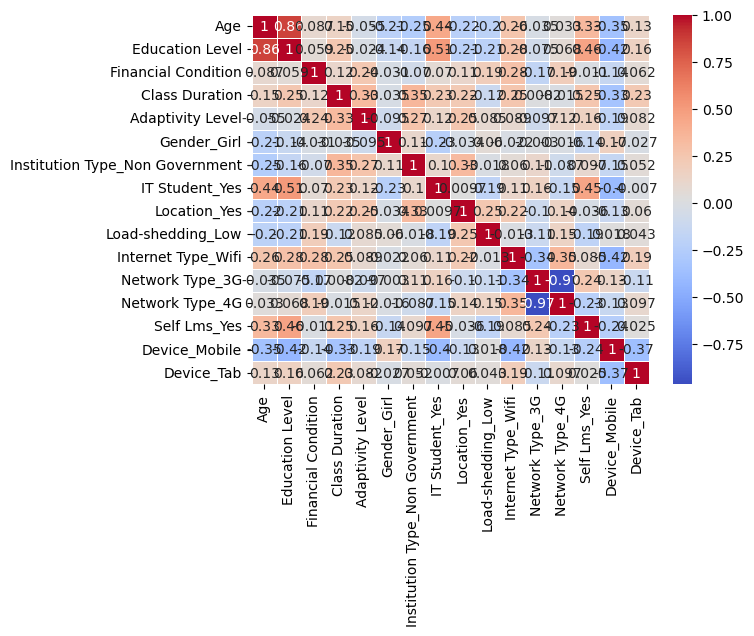

<Figure size 640x480 with 0 Axes>

In [69]:
#Calculate correlation matrix
correlation_matrix=encoded_data.corr()

#Create heatmap with sns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)

#Plotting size
plt.figure(figsize=(150, 120))

#Plotting heatmap
plt.title("Correlation Matrix")
plt.show()

#Save the heatmap
plt.savefig("Heatmap_scatch.png", dpi=300)

Text(0.5, 0, 'Duration')

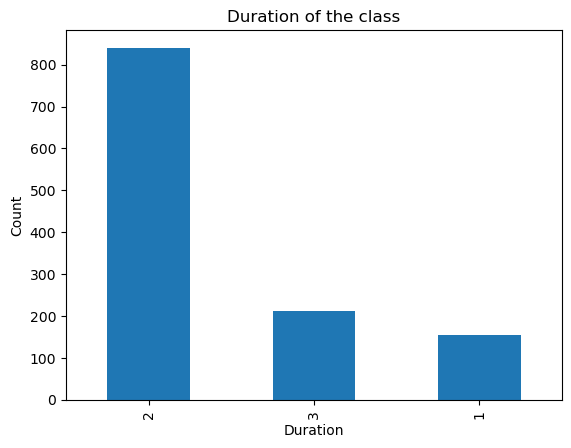

In [70]:
ax = data['Class Duration'].value_counts() \
    .head(10) \
    .plot(kind='bar', title='Duration of the class')
ax.set_ylabel('Count')
ax.set_xlabel('Duration')

Text(0.5, 0, 'Mean')

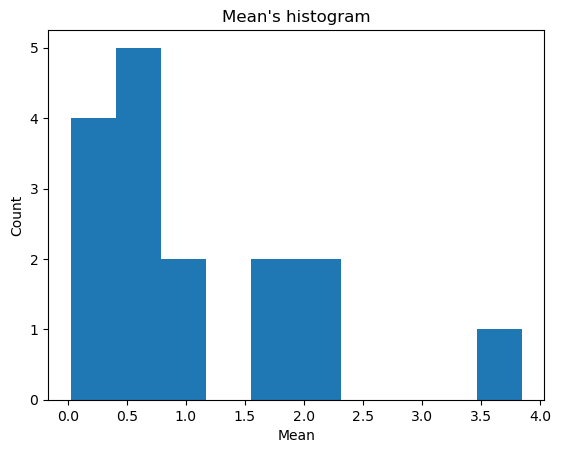

In [56]:
ax=encoded_data.mean() \
    .plot(kind='hist', title="Mean's histogram")
ax.set_ylabel("Count")
ax.set_xlabel("Mean")

Text(0.5, 0, 'Data')

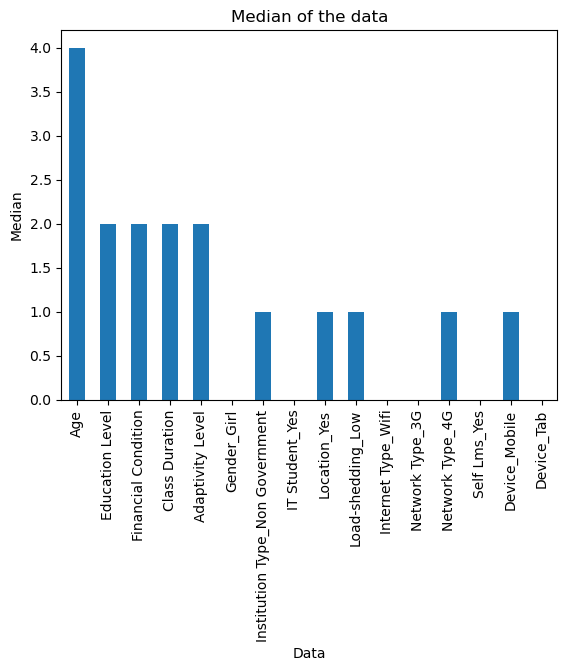

In [75]:
ax=encoded_data.median() \
    .plot(kind='bar', title='Median of the data')
ax.set_ylabel('Median')
ax.set_xlabel('Data')

Text(0.5, 0, 'Data')

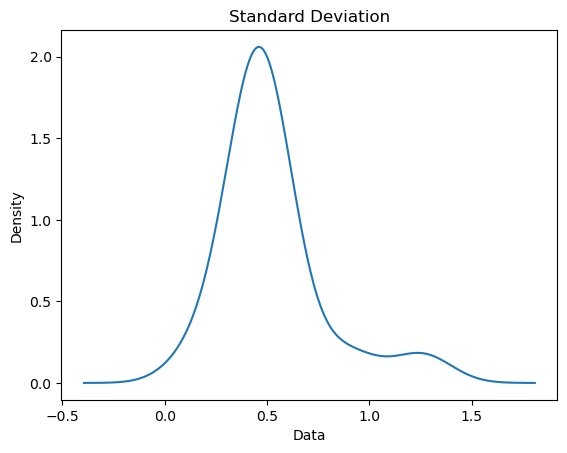

In [78]:
ax = encoded_data.std() \
    .plot(kind='kde', title='Standard Deviation')
ax.set_xlabel('Data')